# Social Finance (online appendix and notes)
**Jonathan Conning**,
Department of Economics, 
Hunter College and The Graduate Center, 
City University of New York

**Jonathan Morduch**, 
NYU Wagner Graduate School of Public Service

*This is a Jupyter Notebook to accompany the paper that offers a summary of main arguments and python code for simulations/visualizations in the paper.*

**Abstract:**  We propose a framework for understanding how social investors’ who seek to maximize a combination of private and social returns from investments in a portfolio of new and established microfinance institutions.  The model takes into account the endogeneity of loan contract terms as well as the capital structure of the financial institutions that may emerge to serve target groups of borrowers differentiated primarily by their levels of initial average net worth, and how social investments might transform those patterns. We build upon one of the workhorse models of modern corporate finance (Tirole, 2007) which features limited liability, multiple layers of moral hazard and costly monitoring to explain patterns of financial intermediation, and in our framework, the role and modes of social investment.  We pinpoint the role of the subsidies and guarantees implicit in social investors’ equity and quasi-equity investments and the role they play in attracting private capital investors and sustaining productivity-enhancing financial intermediation that might otherwise not have taken place. 

# Introduction

...We tackle the logic and tensions inherent in social finance—the support, with philanthropic objectives, of nonprofits, social businesses like the Grameen Bank, and profit-maximizing businesses serving the poor. The principles behind the new world of philanthropy and social action have not been well-explored by economists. We develop a theory of “social finance” to parallel the modern theory of corporate finance... 


## The mobile equity model

We extend a model of capital constraints and financial intermediation with active monitors similar to Holmstrom and Tirole (1997), Conning (1999), but extends the model to focus on how bank capital structure varies across banks depending on the monitoring-intensity of their loan portfolio (determined in turn by the average net worth of its borrowers) and the role that social investors may play in creating and expanding loan access via structured finance. 

This model itself is built upon a simple model of credit rationing due to borrower moral hazard and limited liability, the 'workhorse' model of Tirole's (2006) *The Theory of Corporate Finance*.  Risk-neutral entrepreneurs have access to an investment project which requires a lump-sum investment $I$ to get started, but they do not have liquid funds so they seek to borrow the entire amount from financial intermediaries. The problem of moral hazard will dictate that optimal contracts must reward project success more highly than project failure in order to give entrepreneurs an incentive to want to increase the probability of success.  Under many plausible parameter scenaries te optimal contract will require that loan repayments in the failure state(s) be met out of assets that are additional or 'collateral' to the generated project returns.  Lenders will find it unprofitable to lend to any borrower who cannot credibly pledge assets below a minimum collateral requirement $\underline A$.  A simple graphical analysis of this collateral based lending model is laid out in a notebook [here](basicmodel.ipynb)

Local intermediaries may be able in 'active monitoring' that directly lowers borrowers' scope for moral hazard, lowering the minimum collateral requirements necessary to attract outside investors, thereby expanding capital access.  But monitoring is a costly activity that is itself subject to moral hazard. For this reason an optimal contract will require monitoring intermediaries to have enough of their own capital at risk in a loan so as to provide incentives to appropriately monitor to protect any outside investor's interests. 

In contrast to the earlier mentioned papers, in this paper we posit the idea that local intermediary monitoring capacity is neighborhood-specific, and neighborhoods are largely segregated by the average level of pledgeable assets of its residents.  This leads us to a focus on the optimal capital structure of neighborhood-specific banks (or more broadly to the optimal capital structure of different types of banks, depending on the monitoring intensity of their loan portfolio). 

There are up to four types of agents in the model:

1. risk-neutral entrepreneur households that can run small businesses if they are able to cover lump sum $I$. Household differ in terms of their initial pledgeable assets $A$ (tied up in other projects but can be liquidated at a cost to cover obligations. 
2. one or more local financial intermediaries in each neighborhood, wholly or partly owned and managed by locally informed equity investors. These financial institutions may lend out of their own equity capital. Their own at risk investment in a particular entreprenneur's project is labeled $I^m$ to indicate that they monitor to try to limit scope for moral hazard.
3. private uninformed investors (possibly including savings depositors). 
4. Finally, social investors may be able to affect the nature and depth of the above relationsips through additional investments, subsidies and guarantees of their own. 

Entrepreneurs in neighborhood $j$ have pledgeable assets $A_j$ (assets that are tied up in other productive uses but could be liquidated to pay off a loan).  Depending on the characteristics of the loan projects and the level of $A_j$ the model generates one of four types of lending structures: 

Depending on their initial holding of $A$ and parameters of the problem, entrepreneurs will in the end be either:
1. not funded
2. funded only by a non-leveraged local intermediary, so $I = I^m$
3. funded by a leveraged intermediary: so $I = I^m + I^u$

The model can be closed so that, depending on the characteristics of loans, the initial distribution of pledgeable assets across neighborhoods and entrepreneurs,  and the economy-wide levels of intermediary and uninformed capital we can predict the rate of return on uninformed and intermediary capital as well as bank capital structure and loan terms across the population.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
%matplotlib inline
plt.rcParams['figure.figsize'] = (8.0, 8.0)

## Model parameters

In [2]:
X = 200       # Project returns under success (=0 under failure)
p = 0.97      # probability of success if diligent
q = 0.82      # probability of success if non-diligent
I = 110
 
γ  = 1.1        # outside lenders' cost of funds
Δ = p - q

** Intermediary fixed cost per borrower **

We build into the model the possibility of fixed costs per loan and fixed costs per bank for possible later use, but we'll start the model analysis by setting fixed costs to zero.

In [3]:
F = 0        # Fixed cost just to operate
f = 0
def FC(N):   #Avg fixed cost per borrower if bank has N borrowers
    return F/N + f

**Monitoring technology:** We assume a linear relationship betweeen monitoring intensity $m$ (=monitoring expense) and the extent of moral hazard as captured by the  private benefits $B(m)$ the client stands to capture from non-diligence. 

$$B(m) = B_0 -\alpha \cdot m$$

In [4]:
B0 = 30
α = 0.4
def B(m, B0 = 30, α = 0.4):
    '''Private benefits as a function of monitoring m'''
    return B0 - α*m

### Neighborhoods, Entrepreneurs and assets 
There are $J$ neighborhoods with $N$ enterepreneurs per neighborhood. The neighborhoods are segregated by pledgeable assets or wealth (and to simplify, everyone in a particular neighborhood has the same level of assets as all their neighbors.  A household:

 - in the poorest neighborhood has pledgeable assets $A=0$
 - in the richest neighborhood has $A=A^{max}$
 - in neighborhood $j$ has pledgeable assets $A_j = j \cdot \frac{A^{max}}{J}$


In [5]:
Amax = 120         # highest pledgeable asset value
J = Amax           # number of neighborhoods
N = 1000           # entrepreneurs per neighborhood
pop = J*N          # total population

In [6]:
Nj = N*np.ones(J+1)    
A = np.linspace(0, Amax, J+1)   

Each of the $N$ would-be entrepreneurs in each of the $J$ neighborhoods has potential demand for lump sum investment $I$, so total potential demand is $\bar{K} = N \cdot J \cdot I$


To make the problem interesting we'll start with not enough local intermediary monitoring capital to satisfy this total demand which means financial intermediaries and entrepreneurs will try to raise the remaining funds on the market for uninformed capital.  Uninformed capital investors will participate as long as they can expect to earn the opportunity cost of funds $r$. 

In [7]:
KT = J * N * I    
μ  = 1/2       # fraction of total intermediary capital can supply  
KM = μ * KT    # available intermediary capital  

Let's summarize a few things in our concrete example:

In [8]:
print('There are {} neighborhoods with {} entrepreneurs each'.format(J,N))
print('Total potential loan demand is {:5,.0f}'.format(KT))
print('Local intermediary capital can fund {:5,.0f}'.format(KM))

There are 120 neighborhoods with 1000 entrepreneurs each
Total potential loan demand is 13,200,000
Local intermediary capital can fund 6,600,000


### Minimum collateral requirements

#### Minimum collateral for a no-monitoring lender

Uninformed lenders will require that the borrower pledge a minimum collateral requirement, to be sure they are diligent in their projects so as to generate enough expected returns to allow sufficient repayment. The uninformed lenders may require the participation of a monitoring intermediary lender to lower the scope for moral hazard and with that the loan participation and minimum collateral required to get an uninformed lender to participate.

Let's start by calculating the minimum collateral requirement for direct lending by a (non-monitoring) uninformed lender (the [basicmodel](basicmodel.ipynb) notebook provides further background on this benchmark case). 

The lowest cost way to satisfy the limited liability and the borrower's incentive compatibility constraint:

$$s_f = -A,  s_s = -A + \frac{B(0)}{p-q}$$

This implies a borrower with pledgeable assets $A$ earns a 'limited liability' rent of: 

$$E(s|p)= -A + p\frac{B(0)}{p-q}$$

The lender must be able to cover the opportunity cost of funds. So a lender will just break even and be willing to participate when the poorest borrower has assets :

$$E(x|p) - E(s|p) = \gamma \cdot I$$

$$E(x|p)  + A  - p\frac{B(0)}{p-q} = \gamma \cdot I$$

Solving for $A$ as a function of $m$ gives us the **minimum collateral requirement for a no-monitoring or uninformed lender** who has opportunity cost of funds $\gamma$ but cannot monitor.


$$\underline A^u(0) = \frac{{p \cdot B(0)}}{p-q} 
 - \left[ {pX - \gamma I} \right]$$

If a borrower has pledgeable assets $A$ in excess of the minimum collateral required by an uninformed lender $\underline A(0,N)$ then they'll pledge $\underline A(0,N)$ and borrow entirely from the uninformed lender, so $I = I^u$ and the cost of funds to the borrower in this competitive environment will be $\gamma$

Entrepreneurs with $A \lt \underline A(0,N)$ will have no choice but to try to borrow via a more expensive monitoring local intermediary.

#### Minimum collateral for a monitoring lender
A monitoring intermediary has the advantage of being able to monitor to directly lower the scope for moral hazard via $B(m)$ but they charge a higher cost of funds because (a) they face a higher opportunity cost of funds $\beta > \gamma$ and because (b) they must also be compensated for the cost of monitoring $m$.

Monitoring lowers the private benefit from non-diligence:

$$E(s|p)= -A + p\frac{B(m)}{p-q}$$

but monitoring adds a cost that must be paid for:

$$E(x|p) - E(s|p) = \gamma \cdot I + m$$

The expression below shows how monitoring intensity $m$ can lower the collateral requirement for a monitoring intermediary when they are the only lender:

**Non-leveraged or Equity-only MFI**

$$\underline A^e(m) = \frac{{p \cdot B(m)}}{p-q} 
 - \left[ {pX - \beta I} \right] + m$$
 
Note that 
Since monitoring $m$ must be paid for out of available project surplus, which reduces what is left to the entrepreneur after making all necessary repayments, the parties will in want the minimum amount of monitoring possible.   That is they'll choose a monitoring intensity $m=m(A)$ that just brings the monitoring minimum collateral requirement down in line with available pledgeable assets $A$:

$$\underline A^e(m(A)) = A$$

**Leveraged MFI**

If the local intermediary MFI can leverage outside capital it can potentially substitute cheaper outside financing for more expensive local intermediary (equity) financing. 

An outside lender will however only participate in a financing structure if it can be sure the monitoring intermediary has enough 'skin in the game' to have incentive to monitor the loan at the minimum intensity required for expected repayments to cover the uninformed lender's costs.  

A contract allocates claims as $s_i$ to the entrepreneur, $R_i$ to the monitoring lender and $X_i -R_i - s_i$ to the uninformed lender where $i = S, F$.  The monitor's incentive compatibility constraint requires that they earn more from being diligent in monitoring at expense $m$ than not monitoring:

$$R_s \ge R_f + \frac{m}{p-q} $$

The lowest cost way of satisfying the monitor's incentive constraint implies leaving a monitoring rent of:

$$E(R|p) = R_f + p \cdot \frac{m}{p-q}$$ 

to the intermediary.  If the monitor has no intermediary capital of their own to put at risk then $R_f =0$ and the minimum cost way to provide incentives to the monitor is to set $R_s = m/(p-q)$ which means leaving a rent of $p \cdot \frac{m}{p-q}$.

If the intermediary puts up $I^m$ of the $I$ loan and take first losses then they stand to earn (lose) $R_f = -\beta I^m$ if the project fails and $R_s = -\beta I^m + \frac{m}{p-q}$ if the project succeeds.  Ex-ante competition in the market for intermediation services should lead to zero profits for intermediaries (i.e. the rent driven to zero):

$$-\beta I^m + p \cdot \frac{m}{p-q} = m $$

which implies that competitive drives intermediaries to raise their stake in the project to:

$$\beta I^m = m \cdot \frac{q}{p-q}  $$

The uninformed lender puts up $I^u = I - I^m$ requires that under such a contract the lender just break even:

$$pX + A - p\frac{B(m)}{p-q} = \gamma (I - I^m) + \beta I^m + m $$

solving for $A$ as a function of $m$:

$$\underline A (m) = p \cdot \frac{{ B(m)}}{p-q} 
- \left[ {pX - \gamma I} \right] 
+ \frac{\beta - \gamma}{\beta} \left( \frac{q \cdot m}{p-q} \right )+ m$$

When we compare this to the equity-only loan above we see that there is a tradeoff:  some money is saved by attracting lower cost funds ($\gamma \le \beta$) but incentive costs rise faster as now we must provide incentives to both the borrower and the monitor. 

In [45]:
def AMe(m, β, N=N):
    '''Minimum collateral for non-leveraged or equity-only MFI '''
    return p/(p-q)*B(m) - p*X + β*I + m +F/N

def AM(m, β, N=N):
    '''Minimum collateral for leveraged MFI '''
    return p/(p-q)*B(m) - p*X + γ*I + m + ((β-γ)/β)*(q*m/(p-q)) + F/N

def Abest(m,β, N=N):
    return np.minimum(AMe(m, β, N),AM(m, β, N) )

def Im(m):
    return q*m/(p-q)

In this competitive setting the lender(s) earns zero profits. But we cannot expected project returns exceed the opportunity cost of capital plus monitoring costs. This determines the maximum feasible level of monitoring.  

$$m^{max} = p \cdot X - \beta \cdot I  $$

The two lines cross at AM(m, β) = AME(m, β) or at:

$$\bar m = β I \frac{(p-q)}{q}$$

So any entrepreneur with $A<AM(\bar m)$ would be in an equity-only loan.

In [46]:
def mcross(β):
    return β*I*(p-q)/q

def mmax(β): 
    '''Maximal monitoring @ which equity-only monitor can break even'''
    return p*X - β*I

def Amin(β):
    '''Lowest possible collateral requirement -- at max feasible monitoring'''
    return AMe(mmax(β),β)

At zero monitoring it's obviously cheaper to use uninformed capital which has lower cost $\gamma$ rather than borrow from an local intermediary capital which has opportunity cost $\beta$.  Since the latter type of loans are more expensive, they'll also be associated with higher minimum collateral requirements.  Suppose $\beta = 1.2 \cdot \gamma$, then:

In [47]:
beta = 1.3
print('Ame(0) = {:5.1f}  Am(0) = {:5.1f} '.format(AMe(0,γ*beta), AM(0,γ*beta)))
print('mcross = {:5.1f}   mmax = {:5.1f}   Amin = {:5.1f}'.format(mcross(beta),mmax(beta), Amin(beta)))

Ame(0) = 157.3  Am(0) = 121.0 
mcross =  26.2   mmax =  51.0   Amin =  62.1


In [48]:
mm = np.linspace(0,Amax)
def plotA(beta):
    fig, ax = plt.subplots(1)
    ax.plot(mm, AMe(mm, beta), label='equity only MFI',linestyle=':')
    ax.plot(mm,AM(mm,beta), label='leveraged MFI', linestyle=':')
    ax.plot(mm,Abest(mm, beta),linewidth=3.3)
    ax.set_xlim(0,80), plt.ylim(0,Amax)
    ax.set_title('Minimum Collateral requirement')
    ax.set_xlabel('monitoring intensity $m$')
    ax.set_ylabel('asset $A (m)$')
    mc = mcross(beta)
    Amc = AM(mc,beta)
    mx = mmax(beta)
    Amx = AMe(mx,beta)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.vlines(mc, ymin=0, ymax=Amc, linestyle =':')
    ax.hlines(Amc, xmin=0, xmax=mc, linestyle =':')
    ax.vlines(mx, ymin=0, ymax=Amx, linestyle =':')
    ax.hlines(Amx, xmin=0, xmax=mx, linestyle =':')
    ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

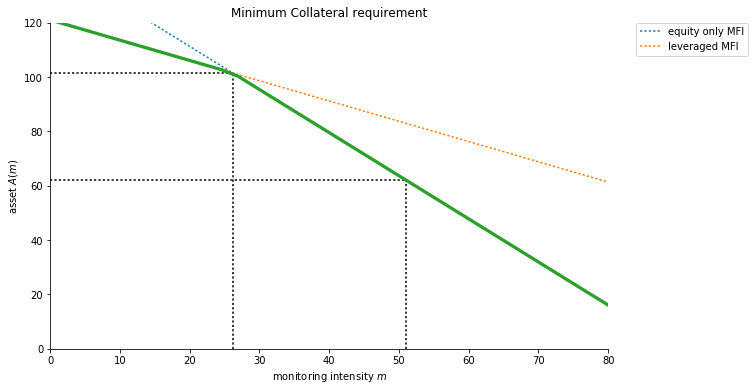

In [49]:
plt.rcParams['figure.figsize'] = (10.0, 6.0)
plotA(1.3)

(NOTE the following calculations assume F= 0)
For any entrepreneur with pledgeable assets $A$ we can find optimal (minimum) amount of monitoring):

$$\underline A^e(m) = A$$
solve for $m$ to get:

$$m^e(A) = \left[ \underline A^e(m)  - A \right] \cdot
    \frac{p-q}{q-(1-\alpha)p}$$
    
If we focus on the entrepreneurs who can get loans with leverage:

$$\underline A(m) = A$$
solve for $m$ to get:

$$m(A) = \left[ \underline A^e(m)  - A \right] \cdot
    \frac{\beta(p-q)}{\beta p(1-\alpha)-\gamma q}$$



In [27]:
def mon(A,β):
    '''optimal monitoring in leveraged MFI
       Zero if >A(0)'''
    AHI = AM(0,γ)
    return (AHI - A)*(β*(p-q))/((α-1)*β*p+γ*q)

def monE(A,β):
    '''optimal monitoring in equity-only MFI'''
    AHI = AMe(0,β)
    return (AHI-A)*((p-q)/(q-(1-α)*p)) 

def minmon(A,β):
    return np.minimum(monE(A,β),mon(A,β))

''

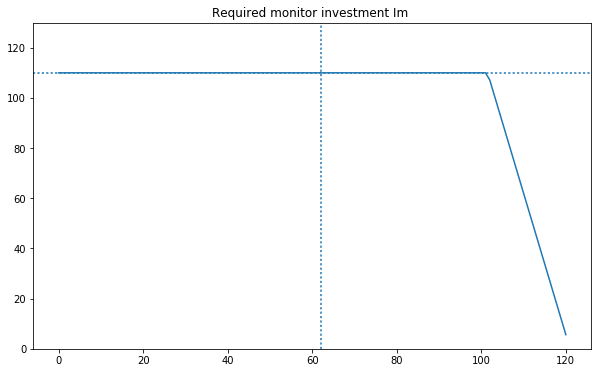

In [43]:
plt.title('Required monitor investment Im ')
plt.plot( np.minimum(I, mon(A,beta)*(q/(p-q))*(1/beta)))
plt.axvline(x=Amin(beta), linestyle =':')
plt.axhline(y=I, linestyle =':')
plt.ylim(0,I+20)
;

## Bringing in the fixed costs

So far we've suppressed the effects of MFI-level fixed costs.  Now we bring them in. 

An **equity-only lender** can only reach as many borrowers $N$ as their equity will allow:

$$N = \frac{K-F}{I} $$

and $m$ will be determined with that $N$ and $\underline A^e(m,N) = A$

The situation is more complicated for a **leveraged lender** as now $m$ and $N$ will be jointly determined.

The local MFI can now reach a larger number of borrowers because is $I^m<I$:

$$N = \frac{K-F}{I^m} $$
$$\underline A^e(m,N) = A$$

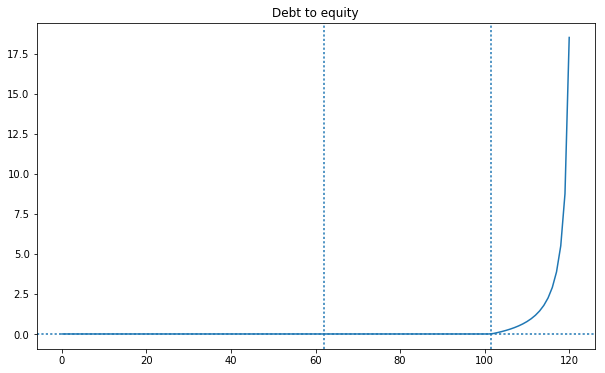

In [44]:
plt.title('Debt to equity ratio')
Im =  np.minimum(I, mon(A,beta)*(q/(p-q))*(1/beta))
de = (I-Im)/Im
plt.plot(de)
plt.axvline(x=AM(mcross(beta),beta), linestyle =':');
plt.axhline(y=0, linestyle =':');
plt.axvline(x=Amin(beta), linestyle =':');


In [21]:
def Breturn(A,β):
    '''borrower return'''
    brt = p*X-γ*I -(β−γ)*(q*mon(A,β)/(p-q))-XXXXX
    brte = 
    A0 = AM(0,β)
    return ((A-AHI)-(β-γ)*I)*((p-q)/(1-α)*p-q) 

SyntaxError: invalid character in identifier (<ipython-input-21-47d4516fee87>, line 3)

NameError: name 'β' is not defined

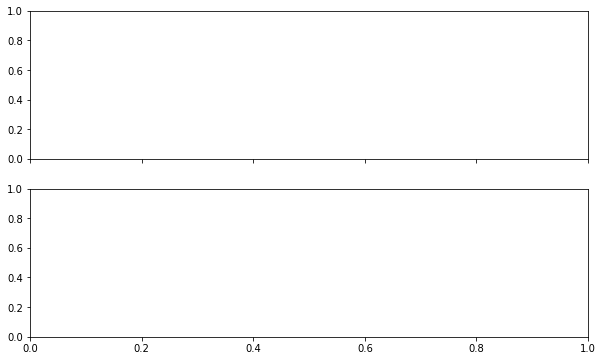

In [66]:
fig, ax = plt.subplots(2, sharex=True)
mx = mmax(β)
equity = q*minmon(A,β)/(p-q)
debt = I - equity
de = np.divide(debt, equity)
Im = q*minmon(A,β)/(β*(p-q))
Im = minmon(A,β)
ax[0].plot(Im,zorder=2)
#ax[0].vlines(AM(0,γ),ymin=30, ymax=mx, linestyle=':',clip_on=False)
#ax[0].vlines(Amin(β),ymin=0, ymax=mx, linestyle=':')

cut = [AM(0,γ),Amin(β),AMe(mcross(β),β)]
for x in cut:
    ax[0].axvline(x=x,ymin=-1,ymax=1,c="red",linestyle=':', zorder=3, clip_on=False)
    ax[1].axvline(x=x,ymin=0,ymax=1,c="red",linestyle=':', zorder=3, clip_on=False)

ax[1].plot(de,zorder=0)
ax[0].set_xlim= ((0, Amax))
ax[0].set_ylim = ((0,mx));

In [ ]:
(69/β)*(q/(p-q))

In [ ]:
AMe(mcross(β),β),AMe(mmax(β),β)

In [ ]:
β*I*(p-q)/q

Monitoring plus incentive costs cannot exceed available surplus

$$pX \ge \gamma I +(\beta-\gamma) \frac{qm}{(p-q)}$$

$$m \le \frac{(p-q)(pX - \gamma I)}{(\beta-\gamma)q} $$



In [ ]:
p*X

In [ ]:
AMe(0,1.2), AM(0,1.2)

In [67]:
def m(A, β):
    return (AMe(0,β) - A)*((p-q)/(q-(1-α)*p))

m(60, β)

NameError: name 'β' is not defined

In [68]:
1/((1-α*p/(p-q)))

-0.6302521008403362

In [69]:
AM(0,1.2)

109.99999999999999

For the case where $\beta = 1.2 \cdot \gamma$ we will have

In [70]:
print('Ame(0) = {:3.1f}  Am(0) = {:3.1f} '.format(AMe(0,γ*1.2), AM(0,γ*1.2)))

Ame(0) = 132.0  Am(0) = 110.0 


In [71]:
p*X - 1.2*I

74.0

This is associated with pledgeable asset level of

In [72]:
AMe(74,1.2)

2.5866666666666447

Putting things together, for this numerical example, Borrowers with pledgeable assets $A$:  

- greater than 100 get direct collateral only loans from uninformed lenders.
- less than 100 but greater than ~85 get leveraged loans.
- less than 85 but above 2.6 get equity only loans. 
- less than 2.6 have no access to credit


**Monitoring intensity, intermediary capital and borrower participation** as a function of pledgeable assets A:

Monitoring loans are more expensive so are only used when necessary and then at minimum monitoring intensity.

Solve for the m that solves:

$$\underline A^e(m) = A$$

$$\frac{{p \cdot B(m)}}{p-q} 
 - \left[ {pX - \beta I} \right] + m  = A$$
 
$$\underline A^e(0) 
+ m \cdot \left[1 -\frac{{p \cdot \alpha m}}{p-q} \right] = A$$

$$m(A) =\frac{ \underline A^e(0) - A }{\left[\frac{{p \cdot \alpha}}{p-q} -1 \right]}$$

where $\underline A^e(0)$ is from the equity-only case.

In [73]:
1/(p*α/(p-q)-((1.2-γ)/1.2)*(1/(p-q)) -1)

0.9698275862068961

In [109]:
1/(p*α/(p-q) -1)

0.6302521008403362

And when we have leveraged lending:

$$m^e(A) =\frac{ A- \underline A^e(0)}{\left[\frac{{p \cdot \alpha}}{p-q}
+ \frac{\beta - \gamma}{\beta} \left( \frac{q}{p-q} \right) - 1
\right]}$$


In [72]:
def mon(A, β):
    '''optimal monitoring intensity in leveraged MFI'''
    Ahi = p*B0/(p-q) - (p*X - γ*I)     #min collateral for no-monitoring loan
    return ((Ahi-A)/(p*α/(p-q)-((β-γ)/β)*(1/(p-q)) -1))

def monE(A, β):
    '''optimal monitoring intensity in equity only MFI'''
    Ahi = p*B0/(p-q) - (p*X - β*I)     #min collateral for no-monitoring loan
    return (Ahi - A)/(p*α/(p-q)-1)

In [73]:
mon(20,1.1), monE(20,1.1)

(81.58220024721878, 56.722689075630235)

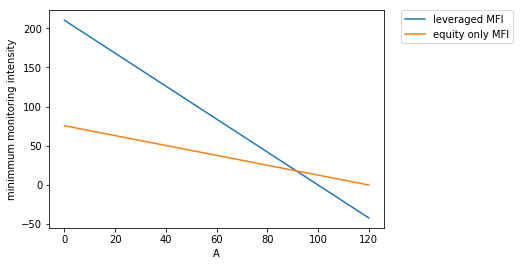

In [74]:
plt.plot(mon(A,1.2),label='leveraged MFI')
plt.plot(monE(A,1.2),label='equity only MFI')
plt.xlabel('A')
plt.ylabel('minimmum monitoring intensity')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.);

In general, the supply of players with _both_ the expertise to monitor the entrepreneur and their own capital to invest in the firm is limited. (Tirole p361) 

**Plot helper functions**.  As we'll be plotting a lot of linear (and non-linear) functions it will be useful to create a simple 'function factory' foto setup lines to be plotted and a plotter function that takes a variable number of line functions to be plotted.

In [55]:
def line_function(a, b):
    '''function factory to return a line function 
    of the form f(x) = a + b*x'''
    def f(x):
        return a + b*x
    return f

def plotter(*args, mmax = 80, title=''): 
    '''plot contract constraints
    Accepts a variable number of lines/constraint functions to plot
    on the same diagram'''
    m = np.linspace(0, mmax, mmax+1)  # plot range
    for count, fn in enumerate(args):              
        plt.plot(m, fn(m))
    ax = plt.gca()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    plt.title(title)
    plt.ylim(0, Amax)  

In [59]:

amb = AMB(m, gamma=1)

SyntaxError: can't assign to function call (<ipython-input-59-c8dd4a6894e4>, line 1)

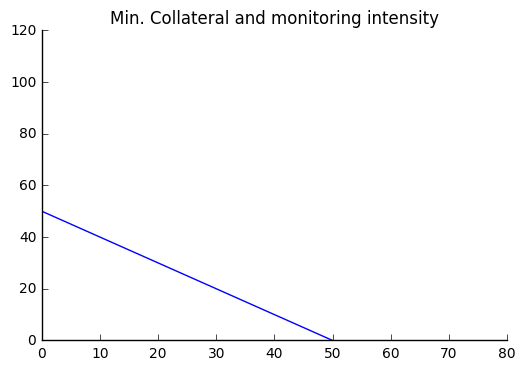

In [57]:
plotter(foo, title='Min. Collateral and monitoring intensity')